In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv('/Users/devammpatel/Desktop/Supervised ML Project on Airbnb Dataset/Dataset/Airbnb_Open_Data_Cleaned.csv')
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country code,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,US,...,193.0,10.0,9.0,10/19/2021,0.210000,4.0,6.0,96.0,Clean up and treat the home the way you'd like...,No license
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,US,...,28.0,3.0,45.0,5/21/2022,0.380000,4.0,2.0,96.0,Pet friendly but please confirm with me if the...,No license
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,unconfirmed,Elise,Manhattan,Harlem,40.80902,-73.94190,US,...,124.0,3.0,0.0,9/9/2021,1.376597,5.0,1.0,96.0,"I encourage you to use my kitchen, cooking and...",No license
3,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,US,...,41.0,10.0,9.0,11/19/2018,0.100000,3.0,1.0,96.0,"Please no smoking in the house, porch or on th...",No license
4,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Michelle,Manhattan,Murray Hill,40.74767,-73.97500,US,...,115.0,3.0,74.0,6/22/2019,0.590000,3.0,1.0,96.0,"No smoking, please, and no drugs.",No license


In [5]:
df.info()  

<class 'pandas.DataFrame'>
RangeIndex: 101368 entries, 0 to 101367
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              101368 non-null  int64  
 1   NAME                            101368 non-null  str    
 2   host id                         101368 non-null  int64  
 3   host_identity_verified          101368 non-null  str    
 4   host name                       101368 non-null  str    
 5   neighbourhood group             101368 non-null  str    
 6   neighbourhood                   101368 non-null  str    
 7   lat                             101368 non-null  float64
 8   long                            101368 non-null  float64
 9   country code                    101368 non-null  str    
 10  instant_bookable                101368 non-null  bool   
 11  cancellation_policy             101368 non-null  str    
 12  room type                  

In [5]:
df.describe()

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.013680e+05,1.013680e+05,101368.000000,101368.000000,101368.000000,101368.000000,101368.000000,101368.000000,101368.000000,101368.000000,101368.000000,101368.000000,101368.000000
mean,2.922075e+07,4.926099e+10,40.728077,-73.949662,2012.485844,625.356706,125.039110,2.889511,15.655641,1.376597,3.278569,7.928350,69.381097
std,1.626204e+07,2.853577e+10,0.055849,0.049476,5.759515,331.226180,66.227256,2.092381,21.986798,1.608609,1.283397,32.286849,54.601945
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,50.000000,10.000000,1.000000,0.000000,0.010000,1.000000,1.000000,0.000000
25%,1.509424e+07,2.459659e+10,40.688730,-73.982570,2008.000000,341.000000,68.000000,2.000000,1.000000,0.280000,2.000000,1.000000,4.000000
50%,2.924071e+07,4.912010e+10,40.722300,-73.954440,2012.000000,625.356706,125.000000,3.000000,7.000000,1.060000,3.000000,1.000000,96.000000
75%,4.328888e+07,7.399645e+10,40.762743,-73.932340,2017.000000,912.000000,182.000000,3.000000,20.000000,1.710000,4.000000,2.000000,96.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,1200.000000,240.000000,14.000000,100.000000,90.000000,5.000000,332.000000,200.000000


In [6]:
df.shape    

(101368, 25)

Let's check the division of data as numeric and categorical data type

In [8]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O'] 
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('The number of numerical features are:', len(numerical_features))
print('The number of categorical features are:', len(categorical_features))

The number of numerical features are: 25
The number of categorical features are: 0


There is clearly some issue here, as we have both the features but here it is only able to detect all features as numeric only. Now we will have to manually assign categorical columns and again run the previous lines

In [6]:
categorical_cols = ['NAME', 'host name', 'neighbourhood group', 'neighbourhood', 'room type', 'host_identity_verified', 'country code', 'house_rules', 'license', 'cancellation_policy']  # list string columns
for col in categorical_cols:
    df[col] = df[col].astype('object')

In [7]:
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O'] 
categorical_features = [feature for feature in df.columns if df[feature].dtype == 'O']
print('The number of numerical features are:', len(numerical_features))
print('The number of categorical features are:', len(categorical_features))

The number of numerical features are: 15
The number of categorical features are: 10


In [13]:
#Proportion of data on categorical features
for feature in categorical_features:
    print('The proportion of data on {} is:'.format(feature))
    print(df[feature].value_counts()/len(df))
    print('----------------------------------')

The proportion of data on NAME is:
NAME
Home away from home                                  0.000326
Water View King Bed Hotel Room                       0.000296
Brooklyn Apartment                                   0.000266
New york Multi-unit building                         0.000266
Private Room                                         0.000227
                                                       ...   
New! 3B2B Bayside/3 blocks to train/25 min to NYC    0.000010
Cozy 1bd in Kensington                               0.000010
Elmhurst 1st Fl Rightl Bedroom                       0.000010
Elmhurst 1st Floor BR w/ Pvt. Bath&Balcony           0.000010
Parisian Style Apartment in Heart of Brooklyn        0.000010
Name: count, Length: 61048, dtype: float64
----------------------------------
The proportion of data on host_identity_verified is:
host_identity_verified
unconfirmed    0.500631
verified       0.499369
Name: count, dtype: float64
----------------------------------
The proportio

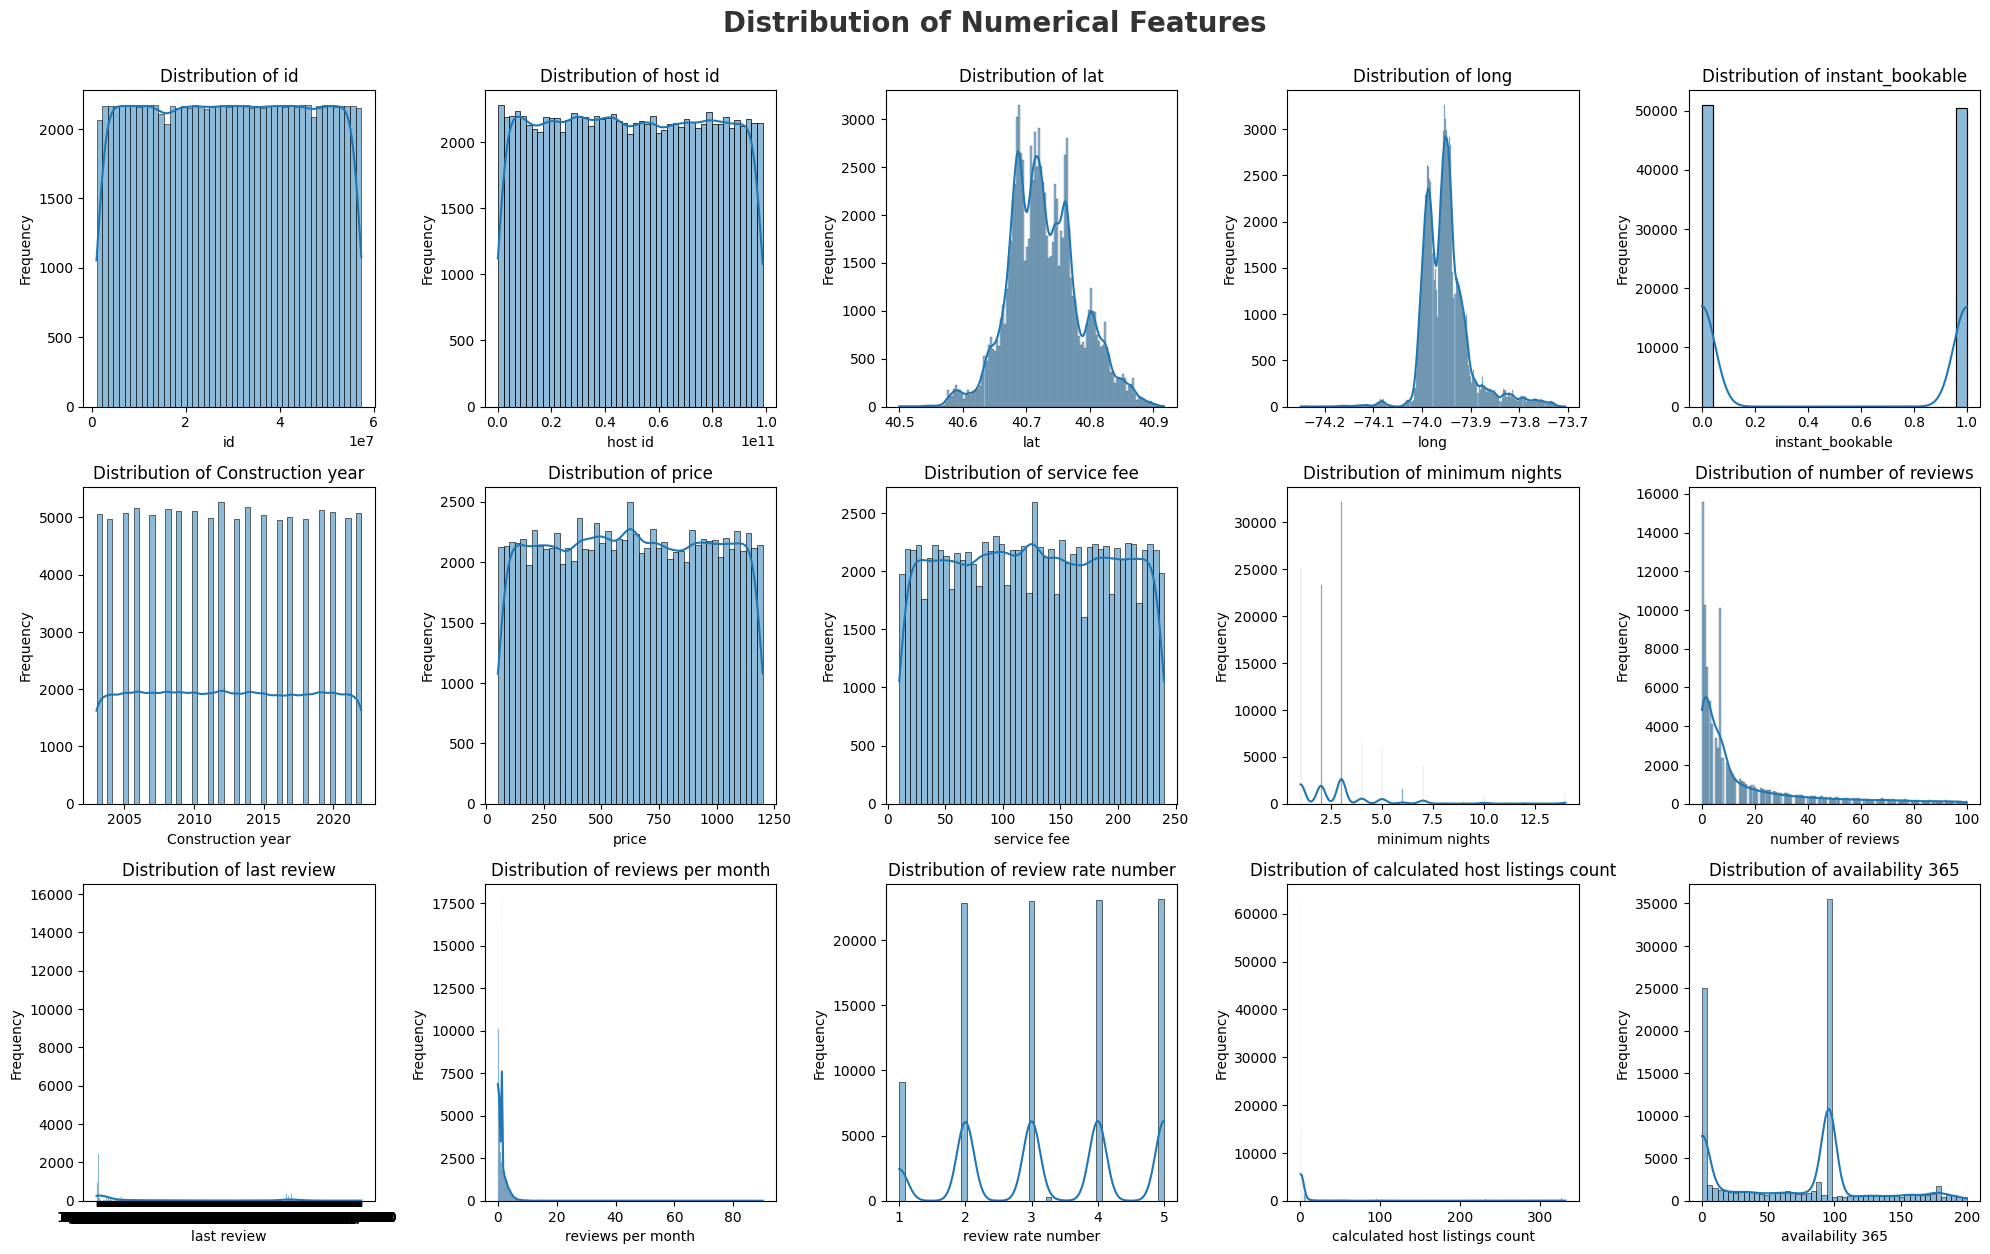

In [28]:
#Proportion of data on numerical features
plt.figure(figsize=(20, 20))
plt.suptitle('Distribution of Numerical Features', fontsize=20, alpha=0.8, y=1., fontweight='bold')
for i, feature in enumerate(numerical_features):
    plt.subplot(5, 5, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title('Distribution of {}'.format(feature))
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
plt.show()

In [30]:
# To ignore the warning
import warnings
warnings.filterwarnings('ignore')

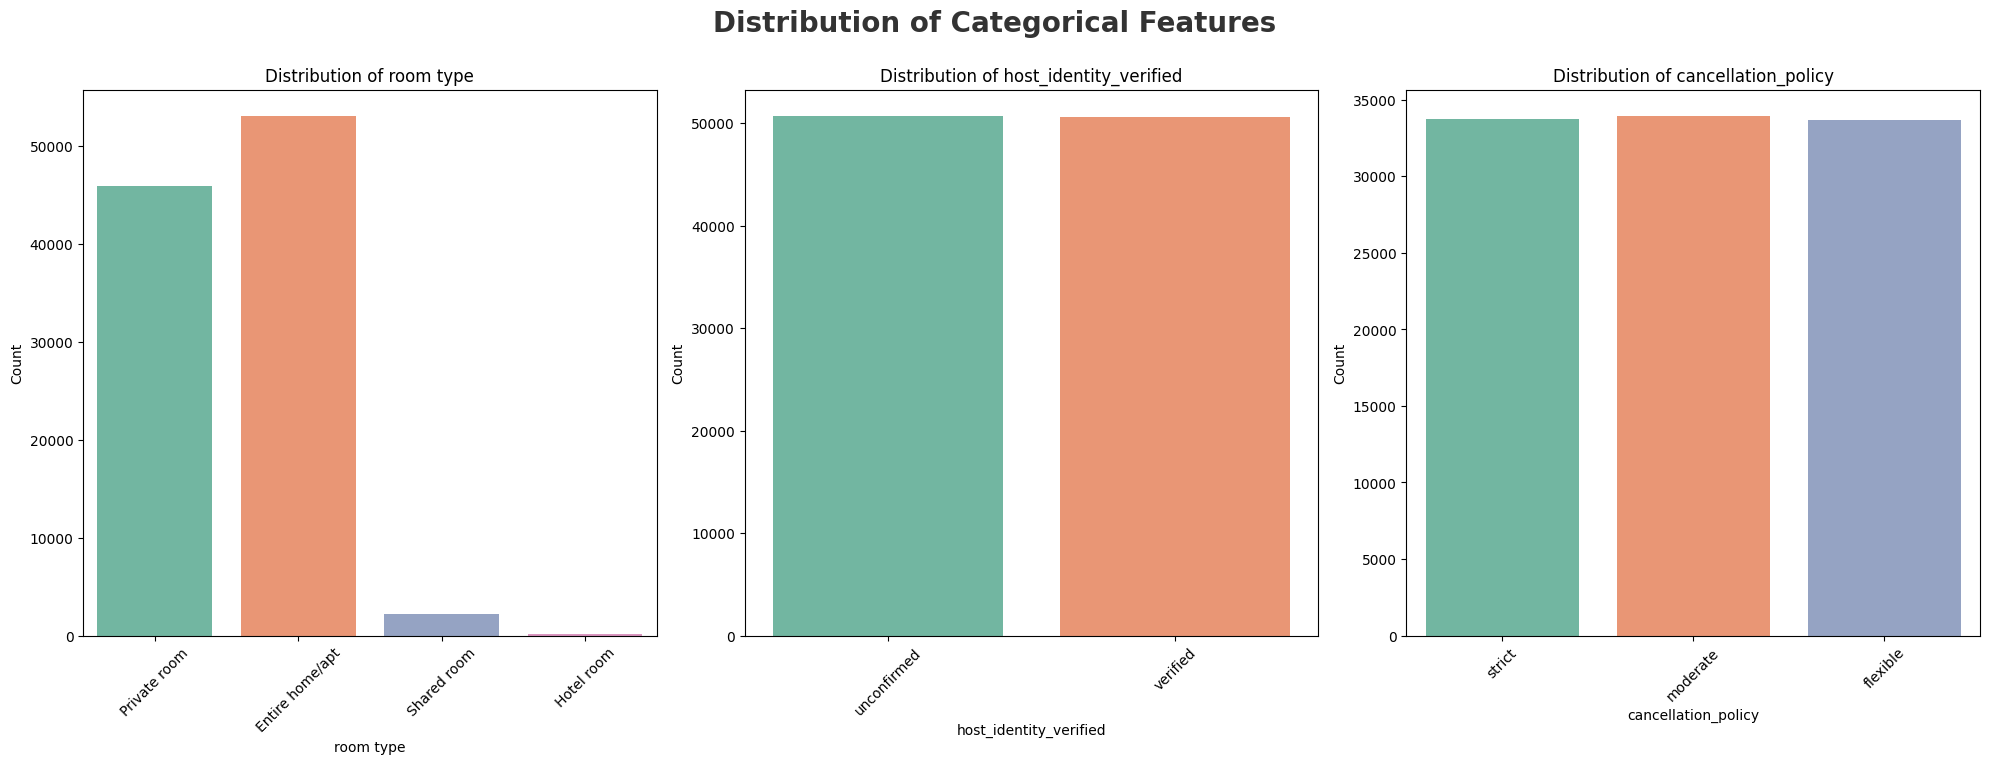

In [31]:
#Categorical features distribution of 'room type', 'host_identity_verified', 'cancellation_policy'
plt.figure(figsize=(20, 20))
plt.suptitle('Distribution of Categorical Features', fontsize=20, alpha=0.8, y=1., fontweight='bold')
category = ['room type', 'host_identity_verified', 'cancellation_policy']    
for i, feature in enumerate(category):
    plt.subplot(3, 3, i+1)
    sns.countplot(x=df[feature], palette='Set2')
    plt.title('Distribution of {}'.format(feature))
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

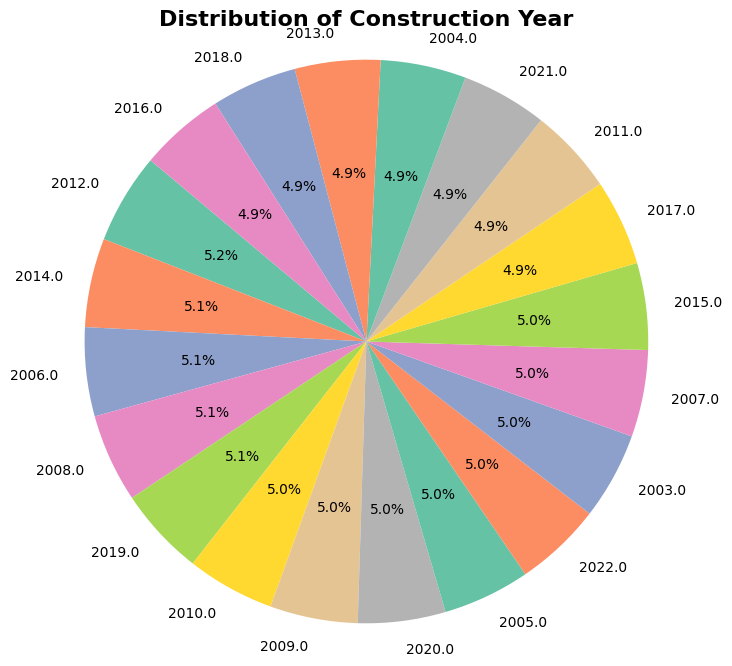

In [33]:
# Let's plot pie chart for 'Construction year' feature
plt.figure(figsize=(8, 8))
plt.pie(df['Construction year'].value_counts(), labels=df['Construction year'].value_counts().index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('Set2'))
plt.title('Distribution of Construction Year', fontsize=16, fontweight='bold')
plt.axis('equal')  # Equal aspect ratio ensures that pie chart is circular
plt.show()